In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

print(digits.data.shape)
print(digits.images.shape)
print(digits.target.shape)

(1797, 64)
(1797, 8, 8)
(1797,)


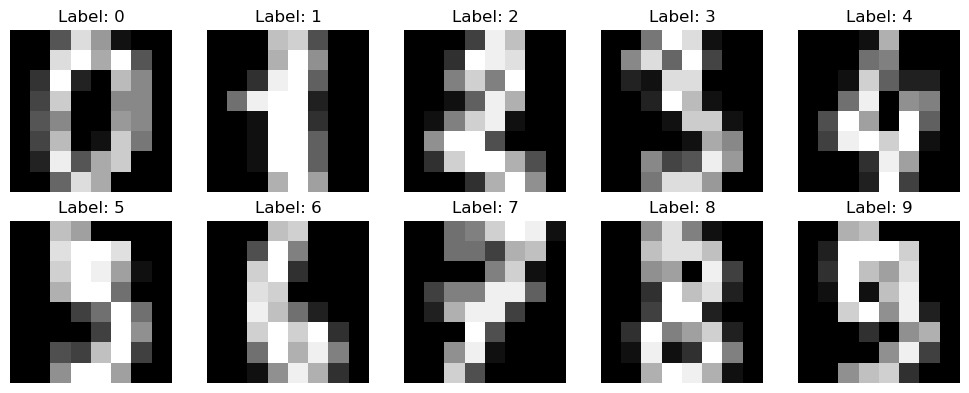

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

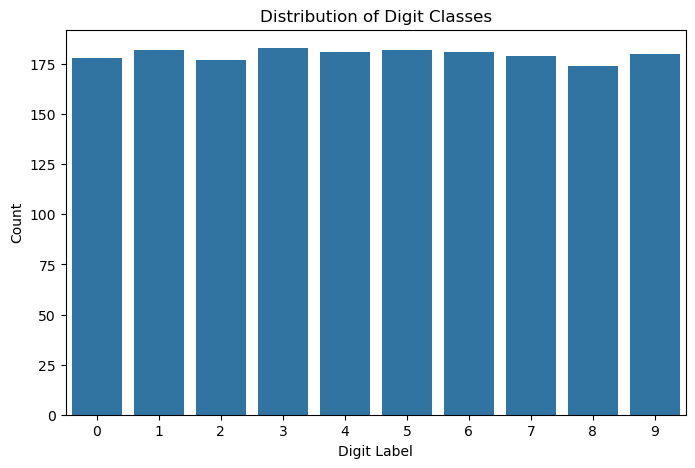

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(x=digits.target)

plt.title("Distribution of Digit Classes")
plt.xlabel("Digit Label")
plt.ylabel("Count")

plt.show()

In [6]:
print("Minimum pixel value:", digits.data.min())
print("Maximum pixel value:", digits.data.max())

Minimum pixel value: 0.0
Maximum pixel value: 16.0


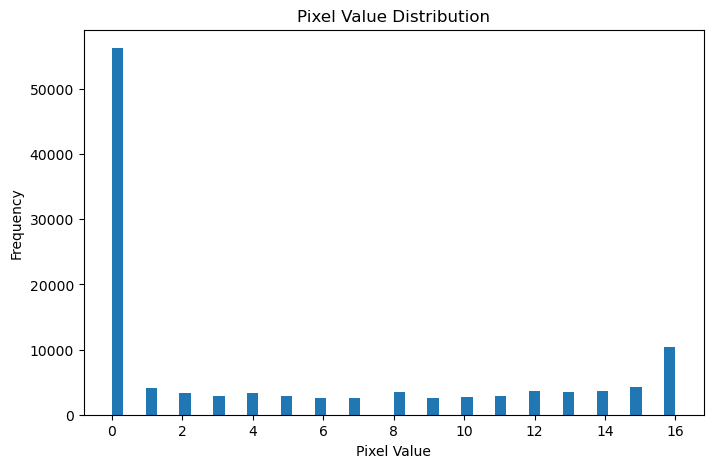

In [7]:
plt.figure(figsize=(8,5))

plt.hist(digits.data.flatten(), bins=50)

plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [8]:
# Normalize pixel values

X = digits.data / 16.0

y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1437, 64)
(360, 64)
(1437,)
(360,)


In [10]:
import torch

# Convert to tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Check shapes

print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([1437, 64])
torch.Size([360, 64])
torch.Size([1437])
torch.Size([360])


In [11]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

print(model)

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=10, bias=True)
)


In [12]:
import torch.optim as optim

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [13]:
for epoch in range(200):

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(outputs, y_train_tensor)

    # Reset gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 2.3147695064544678
Epoch 20, Loss: 2.256378650665283
Epoch 40, Loss: 2.1453635692596436
Epoch 60, Loss: 1.9462469816207886
Epoch 80, Loss: 1.6728307008743286
Epoch 100, Loss: 1.3728749752044678
Epoch 120, Loss: 1.092527985572815
Epoch 140, Loss: 0.8490129709243774
Epoch 160, Loss: 0.6470457911491394
Epoch 180, Loss: 0.4954637289047241


In [14]:
with torch.no_grad():

    outputs_test = model(X_test_tensor)

    _, predicted = torch.max(outputs_test, 1)

print(predicted[:20])

tensor([6, 9, 3, 7, 2, 2, 5, 2, 5, 2, 1, 7, 4, 0, 4, 2, 3, 7, 8, 8])


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_tensor.numpy(),
    predicted.numpy()
)

print("Accuracy:", accuracy)

Accuracy: 0.9222222222222223


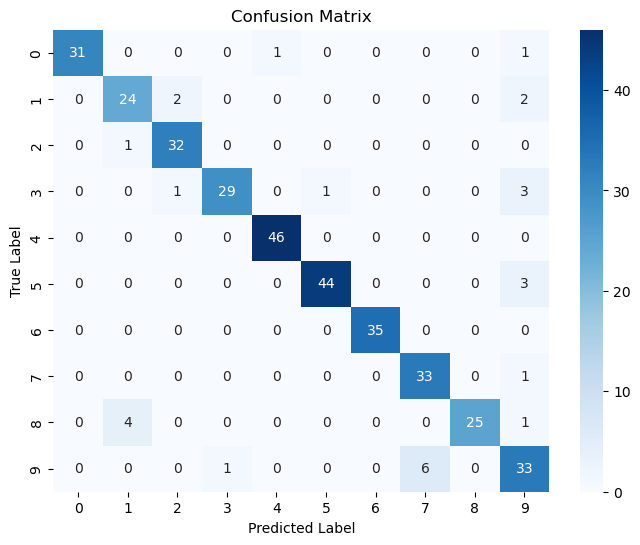

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_tensor.numpy(),
    predicted.numpy()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_tensor.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        33
           1       0.83      0.86      0.84        28
           2       0.91      0.97      0.94        33
           3       0.97      0.85      0.91        34
           4       0.98      1.00      0.99        46
           5       0.98      0.94      0.96        47
           6       1.00      1.00      1.00        35
           7       0.85      0.97      0.90        34
           8       1.00      0.83      0.91        30
           9       0.75      0.82      0.79        40

    accuracy                           0.92       360
   macro avg       0.93      0.92      0.92       360
weighted avg       0.93      0.92      0.92       360



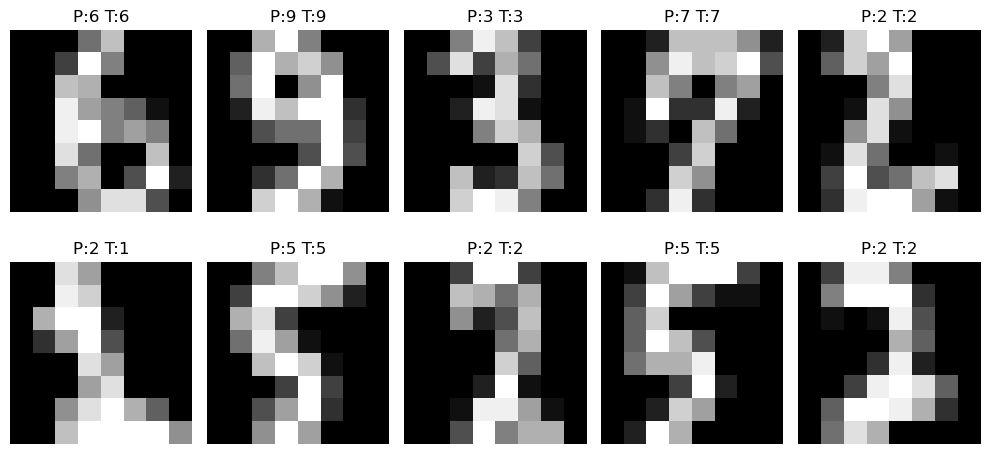

In [18]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(8,8),
        cmap="gray"
    )

    plt.title(
        f"P:{predicted[i].item()} T:{y_test[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
# CNN

In [39]:
X_images = digits.images / 16.0
y = digits.target

# Add channel dimension
X_images = X_images.reshape(-1, 1, 8, 8)

print("X_images shape:", X_images.shape)
print("y shape:", y.shape)

X_images shape: (1797, 1, 8, 8)
y shape: (1797,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_images,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1437, 1, 8, 8)
(360, 1, 8, 8)
(1437,)
(360,)


In [43]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_train_tensor.shape)
print(X_test_tensor.shape)
print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([1437, 1, 8, 8])
torch.Size([360, 1, 8, 8])
torch.Size([1437])
torch.Size([360])


In [45]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(8 * 3 * 3, 32)
        self.relu2 = nn.ReLU()
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu2(x)
        x = self.fc2(x)

        return x

model = CNNModel()
print(model)

CNNModel(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=72, out_features=32, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


In [47]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [51]:
for epoch in range(200):

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(outputs, y_train_tensor)

    # Reset gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 2.07185697555542
Epoch 5, Loss: 2.0222465991973877
Epoch 10, Loss: 1.9655840396881104
Epoch 15, Loss: 1.901713490486145
Epoch 20, Loss: 1.83076810836792
Epoch 25, Loss: 1.753202199935913
Epoch 30, Loss: 1.6698070764541626
Epoch 35, Loss: 1.5817269086837769
Epoch 40, Loss: 1.4904298782348633
Epoch 45, Loss: 1.3976000547409058
Epoch 50, Loss: 1.304842233657837
Epoch 55, Loss: 1.2138402462005615
Epoch 60, Loss: 1.126139521598816
Epoch 65, Loss: 1.0430303812026978
Epoch 70, Loss: 0.965366542339325
Epoch 75, Loss: 0.8936943411827087
Epoch 80, Loss: 0.8281833529472351
Epoch 85, Loss: 0.7687604427337646
Epoch 90, Loss: 0.7151782512664795
Epoch 95, Loss: 0.6670069098472595
Epoch 100, Loss: 0.6237703561782837
Epoch 105, Loss: 0.584935188293457
Epoch 110, Loss: 0.5499933362007141
Epoch 115, Loss: 0.5185038447380066
Epoch 120, Loss: 0.4900388717651367
Epoch 125, Loss: 0.46418315172195435
Epoch 130, Loss: 0.44062361121177673
Epoch 135, Loss: 0.41909343004226685
Epoch 140, Loss: 0.39

In [53]:
with torch.no_grad():
    outputs_test = model(X_test_tensor)
    _, predicted = torch.max(outputs_test, 1)

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_tensor.numpy(), predicted.numpy())
print("CNN Accuracy:", accuracy)

CNN Accuracy: 0.9416666666666667


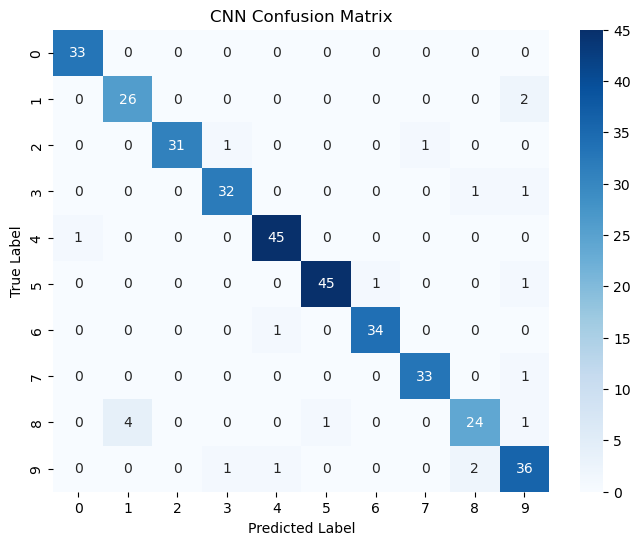

In [63]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_tensor.numpy(), predicted.numpy())

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.show()

In [65]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test_tensor.numpy(), predicted.numpy()))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.87      0.93      0.90        28
           2       1.00      0.94      0.97        33
           3       0.94      0.94      0.94        34
           4       0.96      0.98      0.97        46
           5       0.98      0.96      0.97        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.89      0.80      0.84        30
           9       0.86      0.90      0.88        40

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



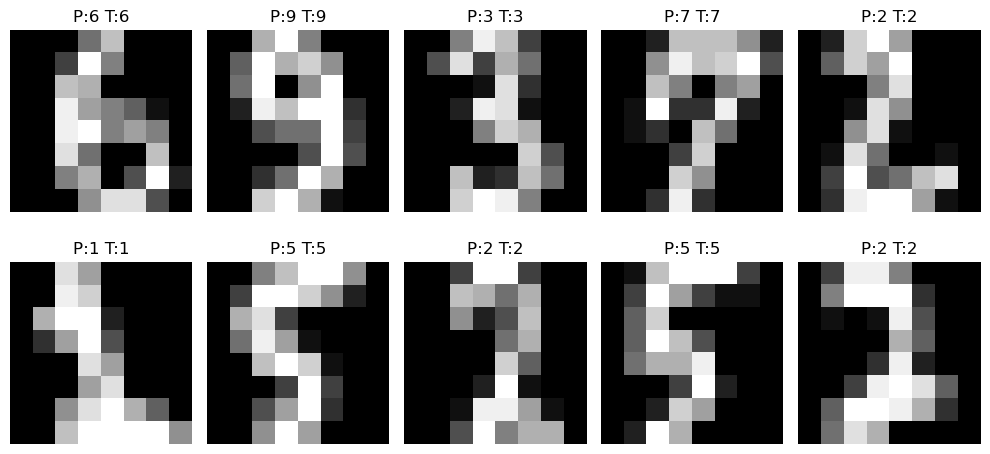

In [61]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap="gray")
    plt.title(f"P:{predicted[i].item()} T:{y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()